### 自动生成线性回归 📈

以下是实现自动生成线性回归的主要步骤：

- **数据准备** 📊：准备用于训练的数据集
- **初始化参数** 🛠️：设定模型的初始参数
- **训练模型** 🏋️：对模型进行训练优化
- **动态图示结果** 📉：以动态图表的形式展示训练结果
- **拓展尝试** 🧪：自己可以尝试使用提示词生成代码


Epoch 98, w=1.6502, b=1.0529, loss=0.1493


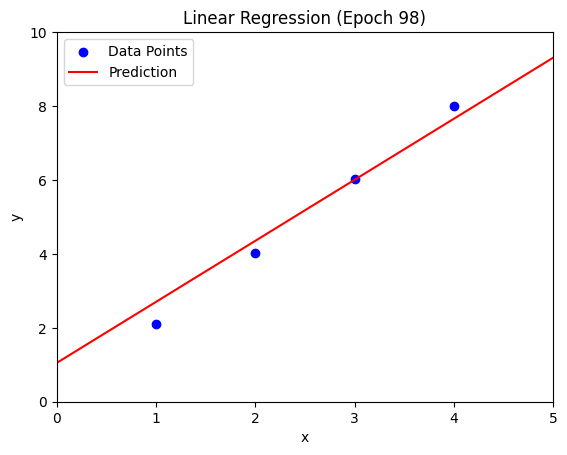

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython import display

# 数据准备
x = torch.tensor([1.0,2.0,3.0,4.0])
y_label = torch.tensor([2.1,4.02,6.03,8.0])

# 初始化参数
w = torch.tensor([1.0],requires_grad=True)
b = torch.tensor([1.0],requires_grad=True)

# 超参设置
epoch = 100
lr = 0.005

plt.figure(figsize=(10, 6))

for i in range(epoch):
    y_pred = w*x + b # 预测值
    loss = torch.nn.functional.mse_loss(y_pred, y_label)
    loss.backward() # 计算梯度

    with torch.no_grad():
        w -= lr*w.grad # 更新参数 w = w - lr*w.grad
        b -= lr*b.grad
        w.grad.zero_() # 梯度清零
        b.grad.zero_()

    if i%2 == 0:  
        display.clear_output(wait=True)
        plt.clf()
        
        # 合并数据转换为列表的操作，简化绘图代码
        x_list, y_label_list = x.tolist(), y_label.tolist()
        plt.scatter(x_list, y_label_list, c='blue', label='Data Points')
        
        x_plot = torch.linspace(0, 5, 100)
        y_plot = w.item() * x_plot + b.item()
        plt.plot(x_plot.tolist(), y_plot.tolist(), 'r-', label='Prediction')
        
        # 合并图表属性设置
        plt.axis([0, 5, 0, 10])
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(f'Linear Regression (Epoch {i})')
        plt.legend()
        
        print(f'Epoch {i}, w={w.item():.4f}, b={b.item():.4f}, loss={loss.item():.4f}')
        plt.pause(0.1)
        display.display(plt.gcf())

plt.show()

### 使用sympy计算sigmoid激活函数及其导函数，并绘制图形 📐
sympy是一个强大的符号计算库，结合matplotlib可以帮助我们可视化sigmoid函数及其导数。

Max derivative value: 0.24996074556221948 at x = -0.02506265664160523


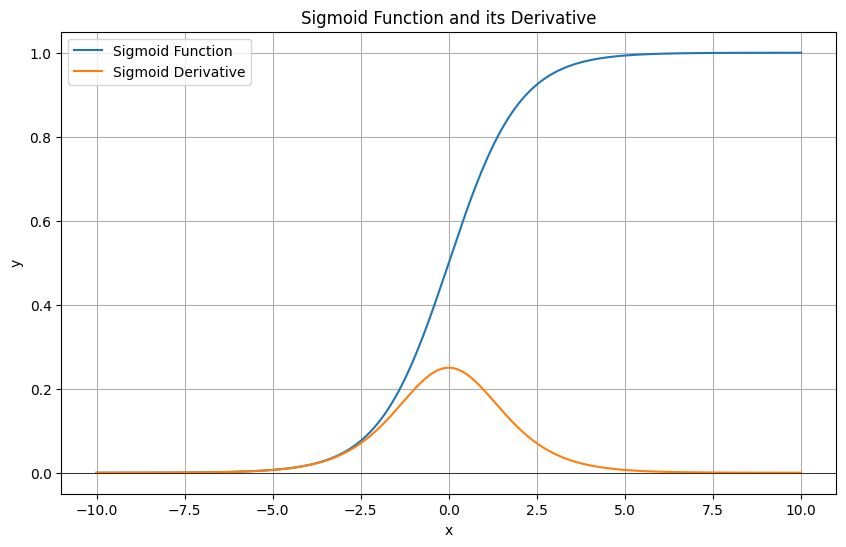

In [3]:
# 需要你补齐的代码
# 最终结果展示
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

x = sp.symbols('x')
sigmoid = 1 / (1 + sp.exp(-x))
sigmoid_derivative = sp.diff(sigmoid, x)

# 计算导数的数值表示
sigmoid_derivative_func = sp.lambdify(x, sigmoid_derivative, 'numpy')


# 绘制sigmoid函数和其导数
x_values = np.linspace(-10, 10, 400)
sigmoid_values = np.array([sigmoid.subs(x, val) for val in x_values])
sigmoid_derivative_values = sigmoid_derivative_func(x_values)
max_derivative = np.max(sigmoid_derivative_values)
max_derivative_x = x_values[np.argmax(sigmoid_derivative_values)]
print(f"Max derivative value: {max_derivative} at x = {max_derivative_x}")

plt.figure(figsize=(10, 6))
plt.plot(x_values, sigmoid_values, label='Sigmoid Function')
plt.plot(x_values, sigmoid_derivative_values, label='Sigmoid Derivative')
plt.axhline(0, color='black',linewidth=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sigmoid Function and its Derivative')
plt.legend()
plt.grid(True)
plt.show()

<details>
<summary>参考答案</summary>

```python
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

x = sp.symbols('x')
sigmoid = 1 / (1 + sp.exp(-x))
sigmoid_derivative = sp.diff(sigmoid, x)

# 计算导数的数值表示
sigmoid_derivative_func = sp.lambdify(x, sigmoid_derivative, 'numpy')


# 绘制sigmoid函数和其导数
x_values = np.linspace(-10, 10, 400)
sigmoid_values = np.array([sigmoid.subs(x, val) for val in x_values])
sigmoid_derivative_values = sigmoid_derivative_func(x_values)
max_derivative = np.max(sigmoid_derivative_values)
max_derivative_x = x_values[np.argmax(sigmoid_derivative_values)]
print(f"Max derivative value: {max_derivative} at x = {max_derivative_x}")

plt.figure(figsize=(10, 6))
plt.plot(x_values, sigmoid_values, label='Sigmoid Function')
plt.plot(x_values, sigmoid_derivative_values, label='Sigmoid Derivative')
plt.axhline(0, color='black',linewidth=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sigmoid Function and its Derivative')
plt.legend()
plt.grid(True)
plt.show()
```
</details>

### Vibecoding练习
BCE and CE 的计算方法和区别

In [4]:
# 帮我举个例子，简单示意下pytorch中 nn.BCELoss的用法，输入是一个[0.8],标签是[1]，分别用库函数和自定义函数计算损失
import torch
import torch.nn as nn
# 使用库函数计算BCELoss
criterion = nn.BCELoss()
input = torch.tensor([0.8], requires_grad=True) # 模型输出的概率值
target = torch.tensor([1.0]) # 真实标签
loss = criterion(input, target)
print(f"BCELoss using library function: {loss.item()}")



BCELoss using library function: 0.2231435328722


In [5]:
#展示一个示例，说明下多分类nn.CrossEntropyLoss的用法，输入是一个二维张量[[0.1, 0.2, 0.7]]，标签是[2]，分别用库函数和自定义函数计算损失
import torch
# 使用库函数计算CrossEntropyLoss
criterion = nn.CrossEntropyLoss()
input = torch.tensor([[0.1, 0.2, 0.7]], requires_grad=True) # 模型输出的概率分布
target = torch.tensor([2]) # 真实标签
loss = criterion(input, target)
print(f"CrossEntropyLoss using library function: {loss.item()}")  


CrossEntropyLoss using library function: 0.7679495811462402


### vibecoding练习
生成MSE和BCE的图形，展示为何MSE不适合分类问题，而BCE更适合分类问题 📊

C:\Users\YMGFC_CN\AppData\Local\Temp\ipykernel_23380\260927484.py:6: RuntimeWarning: divide by zero encountered in log
  bce_loss = - (1 * np.log(x) + (1 - 1) * np.log(1 - x))
C:\Users\YMGFC_CN\AppData\Local\Temp\ipykernel_23380\260927484.py:6: RuntimeWarning: invalid value encountered in multiply
  bce_loss = - (1 * np.log(x) + (1 - 1) * np.log(1 - x))


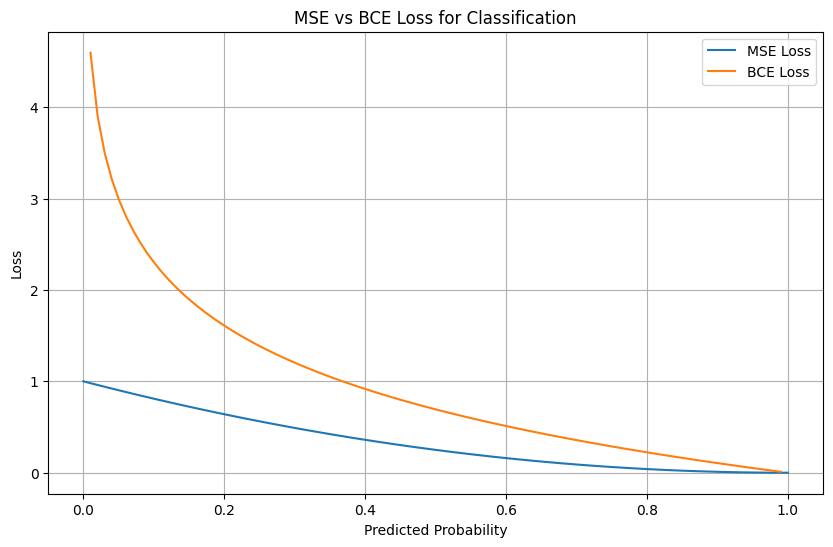

In [6]:
# 生成MSE和BCE的图形，展示为何MSE不适合分类问题，而BCE更适合分类问题
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(0, 1, 100)
mse_loss = (x - 1) ** 2
bce_loss = - (1 * np.log(x) + (1 - 1) * np.log(1 - x))
plt.figure(figsize=(10, 6))
plt.plot(x, mse_loss, label='MSE Loss')
plt.plot(x, bce_loss, label='BCE Loss')
plt.xlabel('Predicted Probability')
plt.ylabel('Loss')
plt.title('MSE vs BCE Loss for Classification')
plt.legend()
plt.grid(True)
plt.show()
#MSE不适合分类问题，因为当预测概率接近0或1时，MSE的损失值较小，无法有效区分正确和错误的分类。
# 而BCE在预测概率接近0或1时会产生较大的损失值，更适合用于分类问题。



<details>
<summary>参考答案</summary>

```python
import numpy as np
import matplotlib.pyplot as plt

# 预测概率（避免0和1，防止log数值问题）
p = np.linspace(1e-6, 1 - 1e-6, 100)

# 以正类样本(y=1)为例
y = 1

# 逐点损失（不是均值标量）
mse = (p - y) ** 2
bce = -(y * np.log(p) + (1 - y) * np.log(1 - p))

plt.figure(figsize=(8, 5))
plt.plot(p, mse, label='MSE (y=1)')
plt.plot(p, bce, label='BCE (y=1)')

plt.xlabel('Predicted Probability')
plt.ylabel('Loss')
plt.title('MSE vs BCE for Binary Classification')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
```
</details>